<a href="https://colab.research.google.com/github/venkatreddych19035/Madelon/blob/main/NISAR_QML_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NISAR GCOV (Jharia) – Stage 1 re-run (QA patches)
Provisional target: **mining vs non-mining**. No label data is downloaded or assumed; no model is trained. Put the `.h5` and `nisar_qml_project.zip` in your Drive home (MyDrive root).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, zipfile
root='/content/drive/MyDrive'
H5='NISAR_S2_PR_GCOV_031_120_D_077_2500_CRNA_A_20260926T125132_20260926T125209_P00500_M_F_I_001.h5'
assert os.path.exists(f'{root}/{H5}'), 'HDF5 not found in Drive home'
print(round(os.path.getsize(f'{root}/{H5}')/1e9,2),'GB')
zipfile.ZipFile(f'{root}/nisar_qml_project.zip').extractall('/content')
%cd /content/nisar_qml

3.23 GB
/content/nisar_qml


In [ ]:
!pip install -q h5py pyproj qiskit pylatexenc python-docx rasterio seaborn tabulate pytest geopandas pyogrio shapely

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.8 MB/s eta 0:00:00


In [ ]:
!cd tests && python -m pytest -q test_core.py 2>&1 | tail -2   # includes the label-gate test

........                                                                 [100%]
8 passed in 5.27s


In [ ]:
# Confirm: the supervised pipeline must REFUSE to run now (labels not reviewed)
!python run_pipeline.py config.yaml 2>&1 | tail -2

Supervised stages are blocked. Label review incomplete: source=none, unconfirmed=['source_approved_by_user', 'temporal_mismatch_reviewed', 'rasterization_method_reviewed', 'label_quality_reviewed'], source description missing.


In [ ]:
# Stage 1 (bbox = lon_min lon_max lat_min lat_max)
!python run_pipeline.py config.yaml --stage1 --set data.bbox=[86.10,86.55,23.62,23.85]

2026-10-06 05:58:59,800 INFO file: /content/drive/MyDrive/NISAR_S2_PR_GCOV_031_120_D_077_2500_CRNA_A_20260926T125132_20260926T125209_P00500_M_F_I_001.h5 (3.23 GB)
2026-10-06 05:59:39,214 INFO ROI rows 2302:3607 cols 6108:8427 -> 1305 x 2319 = 3,026,295 px
2026-10-06 05:59:45,330 INFO validity: {"finite_positive": 0.9999996695629474, "mask_ok": 0.7863106537862303, "exception_ok": 1.0, "noise_ok_if_gamma0": 0.7679737104280977, "noise_ok_if_sigma0": 0.7089094090298533, "noise_ok": 0.7679737104280977, "noise_check": "applied: gamma0 >= NEBS + 3.0 dB (NEBS convention is ambiguous; both variants reported)", "valid_final": 0.7182016293851062}
2026-10-06 06:00:06,399 INFO variogram range 496 m (exponential fit); Moran lag1=0.522
# Stage 1 QA summary (real scene)
- File: `NISAR_S2_PR_GCOV_031_120_D_077_2500_CRNA_A_20260926T125132_20260926T125209_P00500_M_F_I_001.h5`
- ROI window: rows 2302:3607, cols 6108:8427 → **1305 × 2319 = 3,026,295 px** (EPSG:32645, 20 m)
- Outside swath (mask=255): 0.000

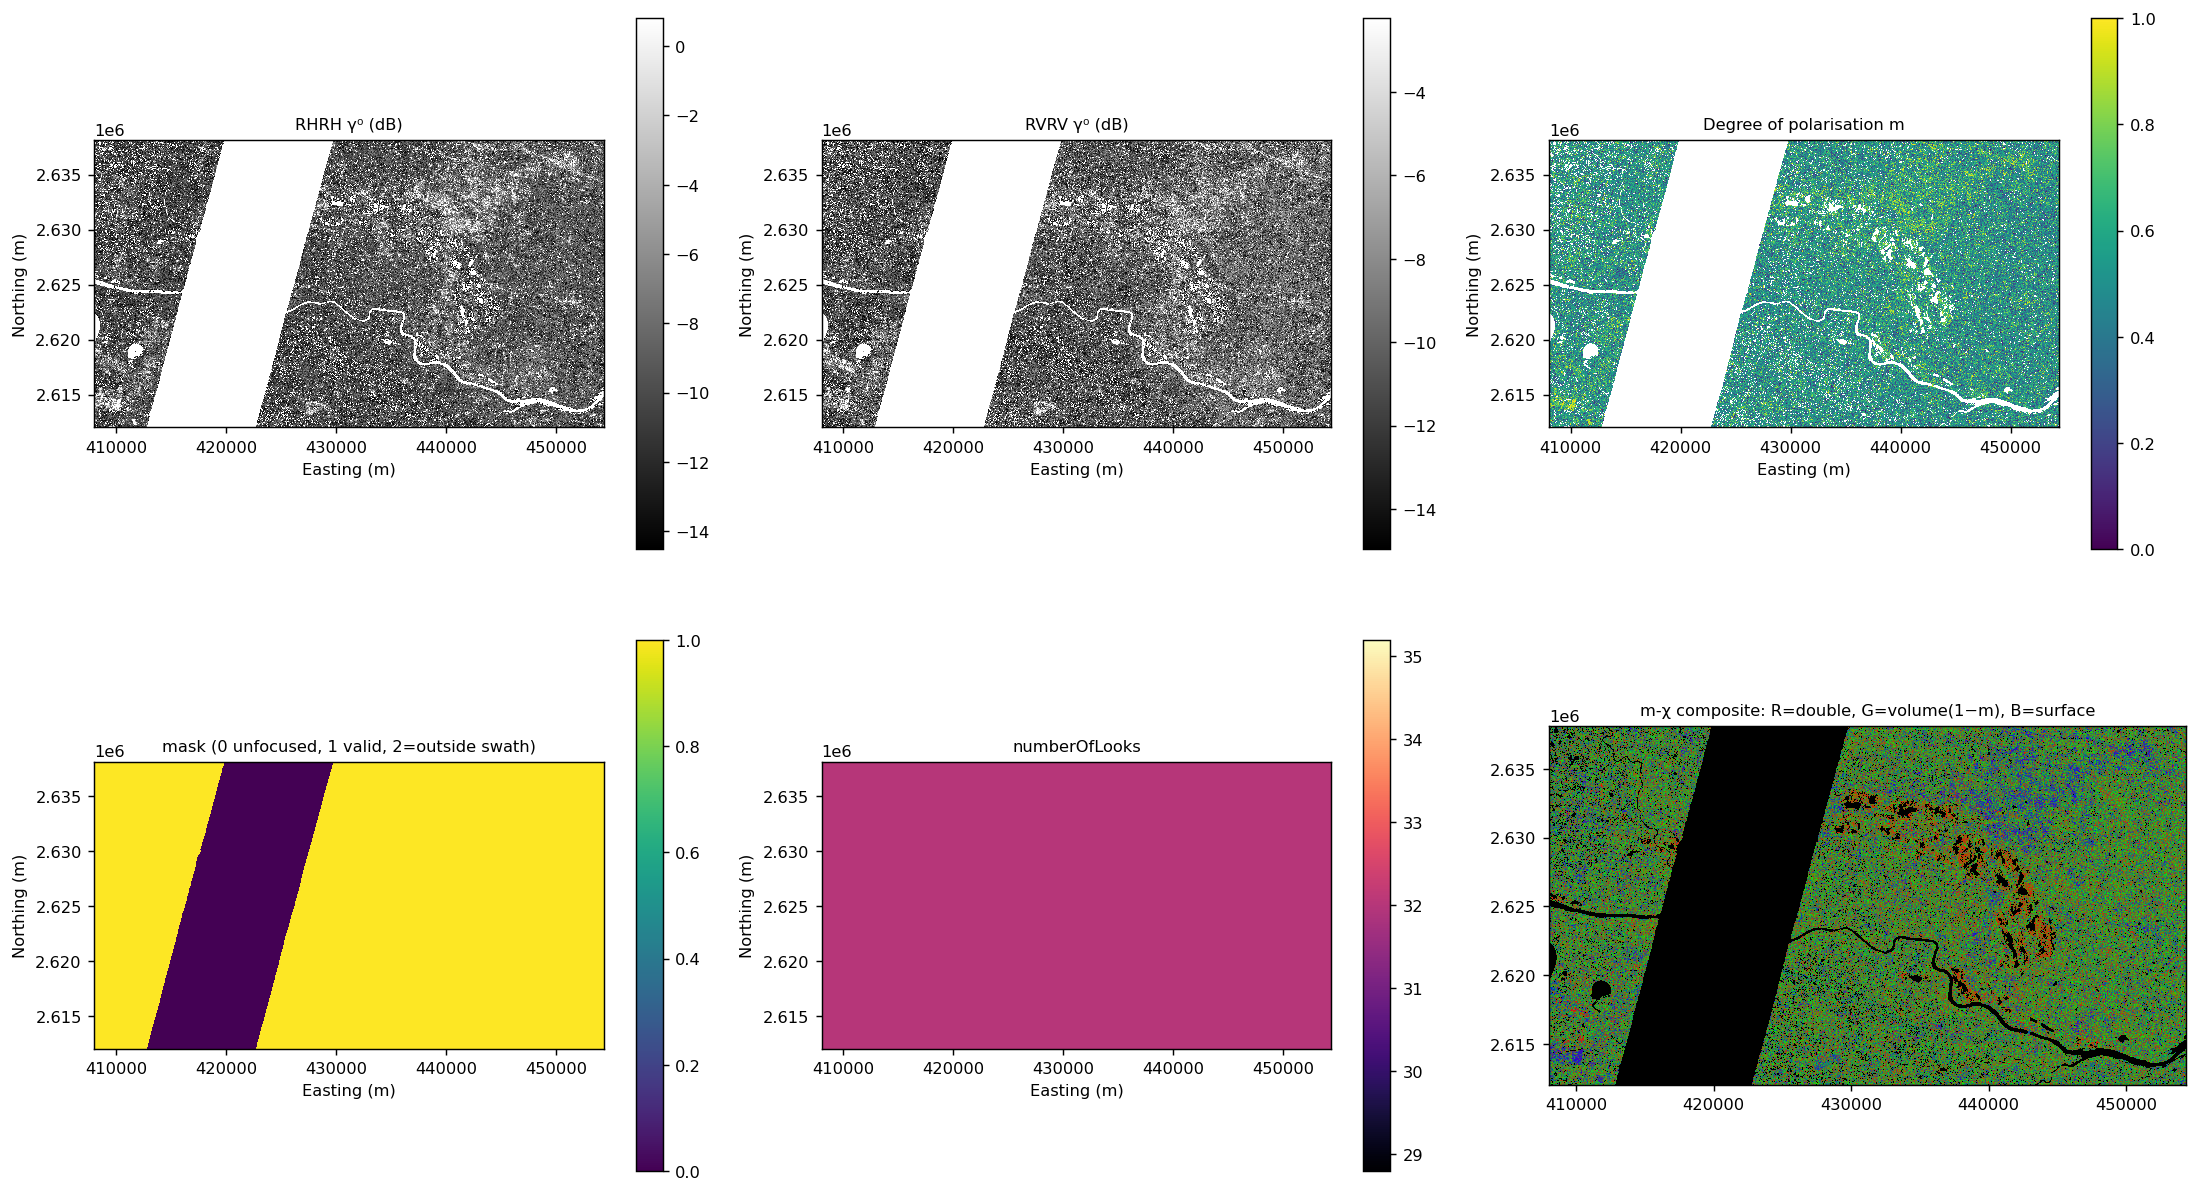

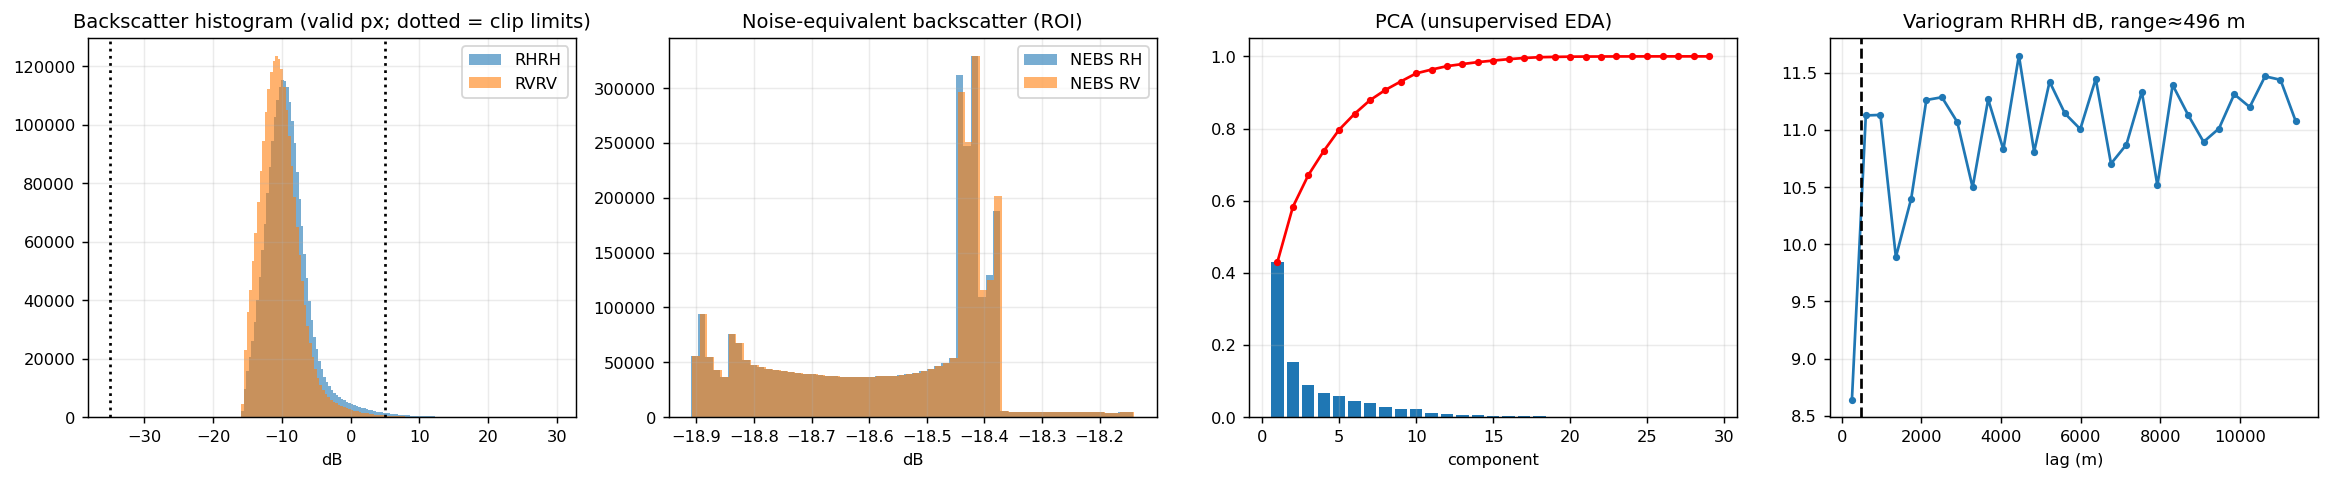

In [ ]:
from IPython.display import Image, display
for f in ['stage1_quicklook','stage1_diagnostics']:
    display(Image(f'/content/nisar_qml_out/stage1/figures/{f}.png'))

In [ ]:
# Collect exactly the six requested deliverables into ONE zip in Drive home (no folders)
import shutil, os
S='/content/nisar_qml_out/stage1'; D='/content/deliverables'; shutil.rmtree(D, ignore_errors=True); os.makedirs(D)
for src,dst in [(f'{S}/STAGE1_QA.md','STAGE1_QA.md'),(f'{S}/STAGE1_QA.json','STAGE1_QA.json'),(f'{S}/figures/stage1_quicklook.png','stage1_quicklook.png'),
                (f'{S}/figures/stage1_diagnostics.png','stage1_diagnostics.png'),(f'{S}/feature_summary.csv','feature_summary.csv'),(f'{S}/config_used.yaml','config_provisional_labels.yaml')]:
    shutil.copy(src, f'{D}/{dst}')
shutil.make_archive('/content/NISAR_stage1_deliverables','zip',D)
shutil.copy('/content/NISAR_stage1_deliverables.zip','/content/drive/MyDrive/NISAR_stage1_deliverables.zip')
print(sorted(os.listdir(D)))
print(open(f'{D}/STAGE1_QA.md').read())

['STAGE1_QA.json', 'STAGE1_QA.md', 'config_provisional_labels.yaml', 'feature_summary.csv', 'stage1_diagnostics.png', 'stage1_quicklook.png']
# Stage 1 QA summary (real scene)
- File: `NISAR_S2_PR_GCOV_031_120_D_077_2500_CRNA_A_20260926T125132_20260926T125209_P00500_M_F_I_001.h5`
- ROI window: rows 2302:3607, cols 6108:8427 → **1305 × 2319 = 3,026,295 px** (EPSG:32645, 20 m)
- Outside swath (mask=255): 0.000
- Mask values: {0: 646687, 1: 2379608}
- Exception values: {0: 3026295}
- Mask×exception cross-tab: {'mask=0|exc=0': 646687, 'mask=1|exc=0': 2379608}
- Validity: {"finite_positive": 1.0, "mask_ok": 0.7863, "exception_ok": 1.0, "noise_ok_if_gamma0": 0.768, "noise_ok_if_sigma0": 0.7089, "noise_ok": 0.768, "noise_check": "applied: gamma0 >= NEBS + 3.0 dB (NEBS convention is ambiguous; both variants reported)", "valid_final": 0.7182}
- numberOfLooks: {"overall": {"p0.1": 32.0, "p1": 32.0, "p5": 32.0, "p50": 32.0, "p95": 32.0, "p99": 32.0}, "frac_below_32": 0.0, "by_mask": {"0": {"p1": 

## Stage 1b: spatial-statistics reconciliation (no labels, no models)
Runs on the saved Stage 1 outputs (`features.npz`, `roi_raw.npz`) in the same Colab session (~minutes).

In [ ]:
!python run_pipeline.py config.yaml --stage1b

# Spatial reconciliation (Stage 1b)
- resolution 20 m; validity variants (pixels): {'final_ok(mask+noise+finite)': 2160423, 'mask1_only(no noise mask)': 2379608}
- current estimator first bins: {'bin_width_m': 386.5, 'mean_lag_first_bins_m': [257.32748178454415, 607.2804253717866, 973.6543901482498, 1360.7944945667236], 'pairs_first_bins': [146, 406, 703, 924], 'pairs_last_bins': [3867, 3871, 3877]}
- spread of the CURRENT estimator (20 subsample seeds):
 n_points  n_bins  bin_width_m   min    p25  median       p75       max  max_over_min
    20000      30        386.0 497.0 2531.0  5115.0   14622.0 3000000.0        6037.0
    20000     116        100.0 599.0 4411.0 11138.0   42534.0 3000000.0        5004.0
   100000      30        386.0 725.0 2001.0  9626.0 1000274.0 3000000.0        4137.0
   100000     116        100.0 393.0 2285.0 29646.0  104590.0 3000000.0        7630.0
- model-free decorrelation distances / fits: see raster_semivariogram_summary.csv
- recommendation (SAR-only ru

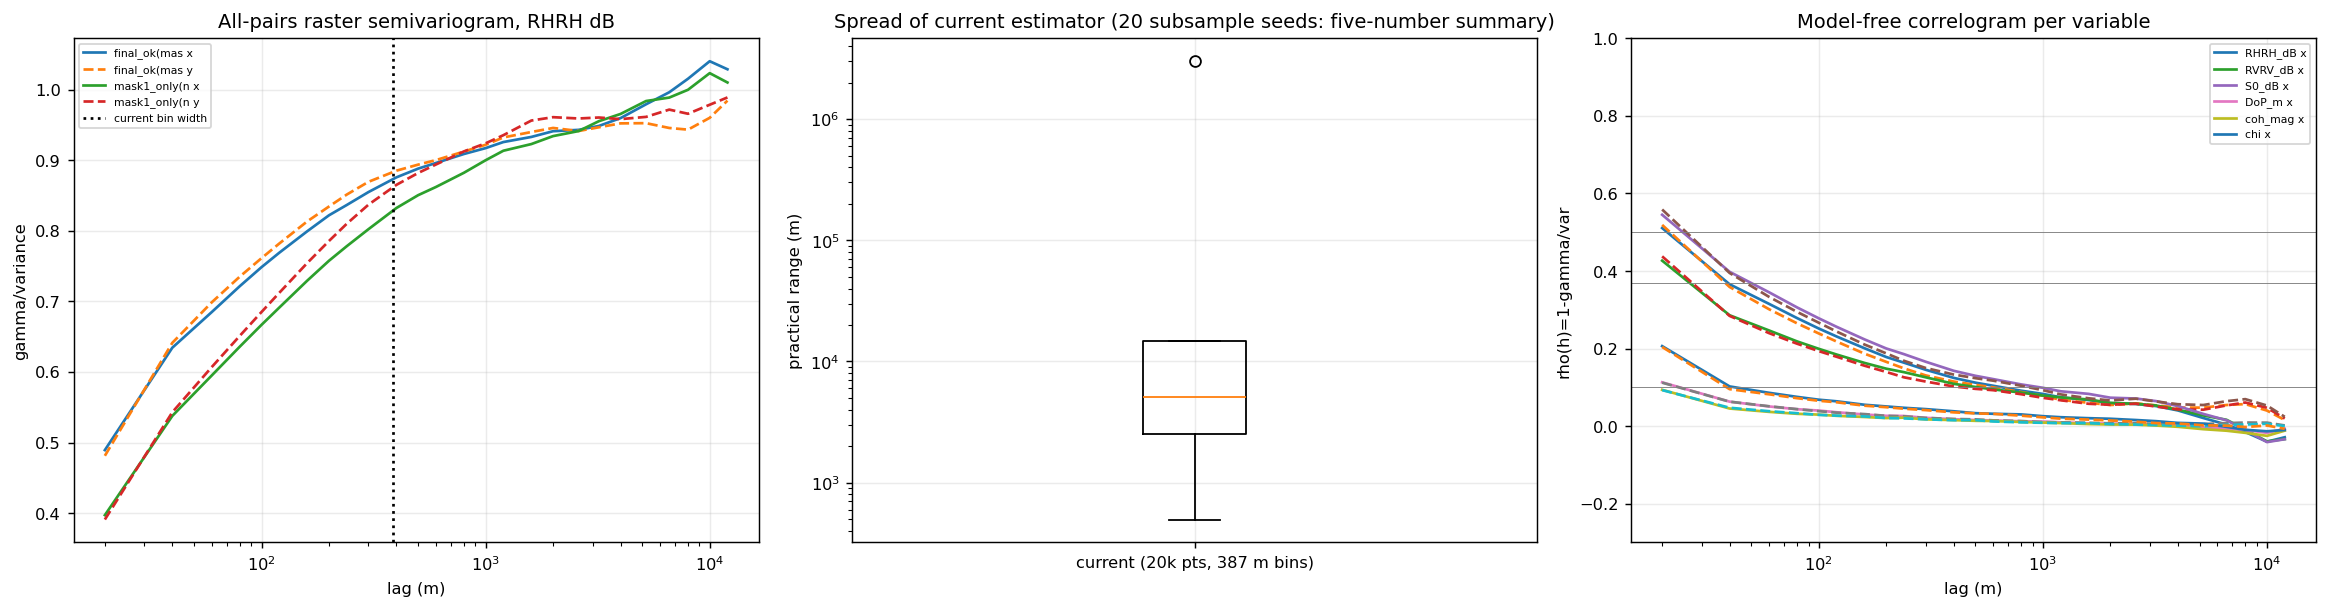

# Spatial reconciliation (Stage 1b)
- resolution 20 m; validity variants (pixels): {'final_ok(mask+noise+finite)': 2160423, 'mask1_only(no noise mask)': 2379608}
- current estimator first bins: {'bin_width_m': 386.5, 'mean_lag_first_bins_m': [257.32748178454415, 607.2804253717866, 973.6543901482498, 1360.7944945667236], 'pairs_first_bins': [146, 406, 703, 924], 'pairs_last_bins': [3867, 3871, 3877]}
- spread of the CURRENT estimator (20 subsample seeds):
 n_points  n_bins  bin_width_m   min    p25  median       p75       max  max_over_min
    20000      30        386.0 497.0 2531.0  5115.0   14622.0 3000000.0        6037.0
    20000     116        100.0 599.0 4411.0 11138.0   42534.0 3000000.0        5004.0
   100000      30        386.0 725.0 2001.0  9626.0 1000274.0 3000000.0        4137.0
   100000     116        100.0 393.0 2285.0 29646.0  104590.0 3000000.0        7630.0
- model-free decorrelation distances / fits: see raster_semivariogram_summary.csv
- recommendation (SAR-only ru

In [ ]:
from IPython.display import Image, display
display(Image('/content/nisar_qml_out/stage1b/spatial_reconciliation.png'))
print(open('/content/nisar_qml_out/stage1b/SPATIAL_RECONCILIATION.md').read())

In [ ]:
import shutil
shutil.make_archive('/content/NISAR_stage1b','zip','/content/nisar_qml_out/stage1b')
shutil.copy('/content/NISAR_stage1b.zip','/content/drive/MyDrive/NISAR_stage1b.zip'); print('saved NISAR_stage1b.zip to Drive home')

saved NISAR_stage1b.zip to Drive home


## Stage 2a: label-source feasibility audit (Maus et al. 2022 v2). No training, no review flags.
Needs the Stage 1 outputs from this session (`features.npz`, `roi_raw.npz`). If the session was restarted, the first cell re-runs Stage 1 (minutes). The audit downloads the OFFICIAL files from PANGAEA (`global_mining_polygons_v2.gpkg` ~23.5 MB, `validation_points_v2.gpkg`) unless they already sit in your Drive home; it records the SHA-256.

In [ ]:
import os
if not os.path.exists('/content/nisar_qml_out/stage1/features.npz'):
    !python run_pipeline.py config.yaml --stage1 --set data.bbox=[86.10,86.55,23.62,23.85]
print('stage1 outputs present:', os.path.exists('/content/nisar_qml_out/stage1/features.npz'))

stage1 outputs present: True


In [ ]:
!python run_pipeline.py config.yaml --label-audit

2026-10-06 06:00:47,945 INFO downloaded https://download.pangaea.de/dataset/942325/files/global_mining_polygons_v2.gpkg -> /content/nisar_qml_out/label_audit/source/global_mining_polygons_v2.gpkg (24.66 MB)
2026-10-06 06:00:49,002 INFO downloaded https://download.pangaea.de/dataset/942325/files/validation_points_v2.gpkg -> /content/nisar_qml_out/label_audit/source/validation_points_v2.gpkg (0.23 MB)
2026-10-06 06:01:08,686 INFO label audit decision: C. REJECT


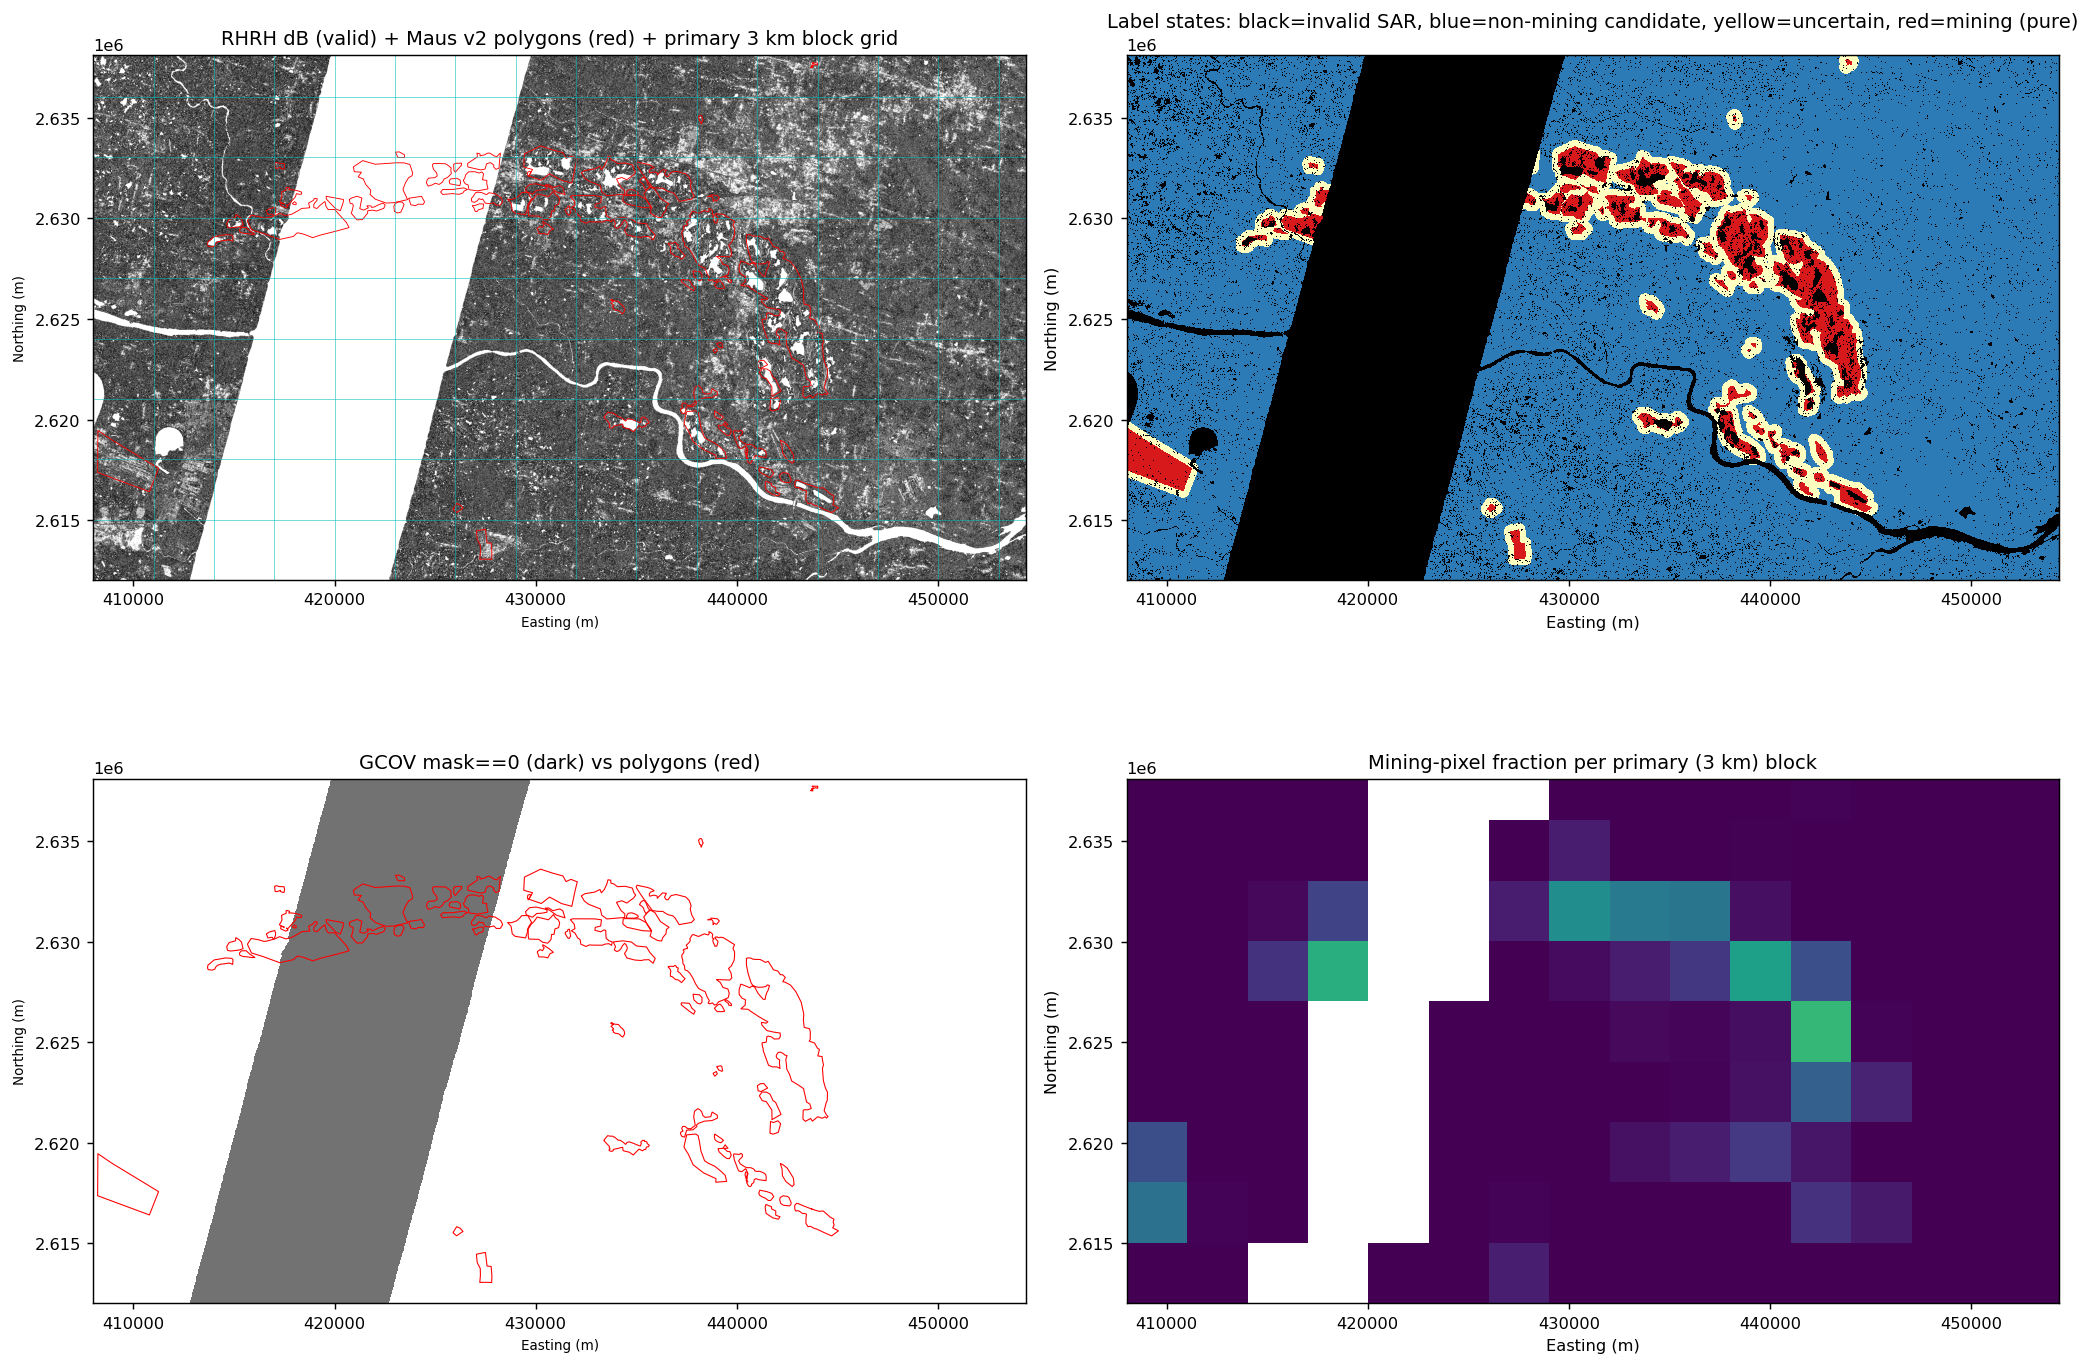

# LABEL_SOURCE_AUDIT: Maus et al. (2022) global mining polygons v2 vs the NISAR Jharia ROI

**Status of the source: historical/weak labels. NOT ground truth, NOT 2026 information. No model was trained; no `labels.review.*` flag was set.**

## Decision (rule fixed in advance in config `label_audit.decision`)

### C. REJECT

Criteria ([x] = satisfied; REJECT rows are guard conditions, i.e. [ ] on a REJECT row means REJECT):

- [x] REJECT: clipped area >= 1.0 km2
- [x] REJECT: split feasible for all seeds (primary protocol)
- [ ] REJECT: min positives per side >= 3000
- [x] APPROVE: integrity_pass
- [x] APPROVE: polygon area fraction in [0.01, 0.5]
- [ ] APPROVE: max complex-leak fraction <= 0.25 (worst seed 0.996)
- [x] APPROVE: mask0 enrichment in [0.67, 1.5] (observed 0.897)
- [x] APPROVE: polygon-pixel validity loss <= 0.40 (observed 0.396)
- [ ] APPROVE: >= 5 test complexes in every seed (min 2)

## 1. What the source is (documented; sources: https://doi.pangaea.de/10.1594/PANGAEA.94

In [ ]:
from IPython.display import Image, display
A='/content/nisar_qml_out/label_audit'
display(Image(f'{A}/label_overlay.png'))
print(open(f'{A}/LABEL_SOURCE_AUDIT.md').read())

In [ ]:
import shutil, os
D='/content/label_deliverables'; shutil.rmtree(D, ignore_errors=True); os.makedirs(D)
for f in ['LABEL_SOURCE_AUDIT.md','mining_polygon_roi.geojson','LABEL_AUDIT_SUMMARY.csv','label_overlay.png','rasterization_spec.json']:
    shutil.copy(f'{A}/{f}', f'{D}/{f}')
shutil.make_archive('/content/NISAR_label_audit','zip',D)
shutil.copy('/content/NISAR_label_audit.zip','/content/drive/MyDrive/NISAR_label_audit.zip'); print(sorted(os.listdir(D)))

['LABEL_AUDIT_SUMMARY.csv', 'LABEL_SOURCE_AUDIT.md', 'label_overlay.png', 'mining_polygon_roi.geojson', 'rasterization_spec.json']


## Stage 3: LABEL-FREE classical vs quantum-kernel clustering (pre-registered)
Read `docs/PREREGISTRATION_UNSUPERVISED.md` first. Uses only Stage 1 features (no labels, no polygons). Expected runtime: minutes on Colab CPU. The quantum kernel is an exact noiseless statevector SIMULATION.

In [ ]:
import os
if not os.path.exists('/content/nisar_qml_out/stage1/features.npz'):
    !python run_pipeline.py config.yaml --stage1 --set data.bbox=[86.10,86.55,23.62,23.85]
print(open('docs/PREREGISTRATION_UNSUPERVISED.md').read()[:1500])

# Pre-registration: label-free classical vs quantum-kernel clustering on NISAR GCOV (Jharia)

Written BEFORE any unsupervised result existed. Values live in `config.yaml` (`unsupervised`, `spatial_cv`). No label source is used or approved; `labels.review.*` remain false.

## Question
Under a leakage-controlled spatial design, do a ZZ-fidelity quantum kernel and an RBF kernel (identical algorithm, identical data, identical representation) produce clusterings that differ in (i) transfer across spatially separated blocks, (ii) initialisation stability, (iii) local spatial coherence, (iv) common-geometry silhouette, and what do they cost?
There is NO accuracy, so no 'predictive advantage' can be claimed. Computational claims are restricted to simulation cost.

## Data and splits
Stage-1 usable pixels (`ok`). Primary spatial protocol: 3 km blocks, 1 km gap (inset 0.5 km). Sensitivity: 1.5 km/0.5 km and 6 km/2 km, run for k in {4, 8}, K=5. Per seed: blocks (>= 200 usable interior pixels) are

In [ ]:
!python run_pipeline.py config.yaml --unsup

2026-10-06 06:01:13,600 INFO features (1305, 2319, 29), usable 2,160,423
2026-10-06 06:01:26,911 INFO [primary:primary_1km_gap_3km_block] seed 42 k=2 done (12 rows)
2026-10-06 06:01:41,866 INFO [primary:primary_1km_gap_3km_block] seed 42 k=4 done (24 rows)
2026-10-06 06:01:59,978 INFO [primary:primary_1km_gap_3km_block] seed 42 k=6 done (36 rows)
2026-10-06 06:02:21,597 INFO [primary:primary_1km_gap_3km_block] seed 42 k=8 done (48 rows)
2026-10-06 06:02:49,795 INFO [primary:primary_1km_gap_3km_block] seed 42 k=10 done (60 rows)
2026-10-06 06:03:34,481 INFO [primary:primary_1km_gap_3km_block] seed 42 k=full done (69 rows)
2026-10-06 06:03:48,521 INFO [primary:primary_1km_gap_3km_block] seed 7 k=2 done (81 rows)
2026-10-06 06:04:02,905 INFO [primary:primary_1km_gap_3km_block] seed 7 k=4 done (93 rows)
2026-10-06 06:04:19,225 INFO [primary:primary_1km_gap_3km_block] seed 7 k=6 done (105 rows)
2026-10-06 06:04:39,323 INFO [primary:primary_1km_gap_3km_block] seed 7 k=8 done (117 rows)
2026-

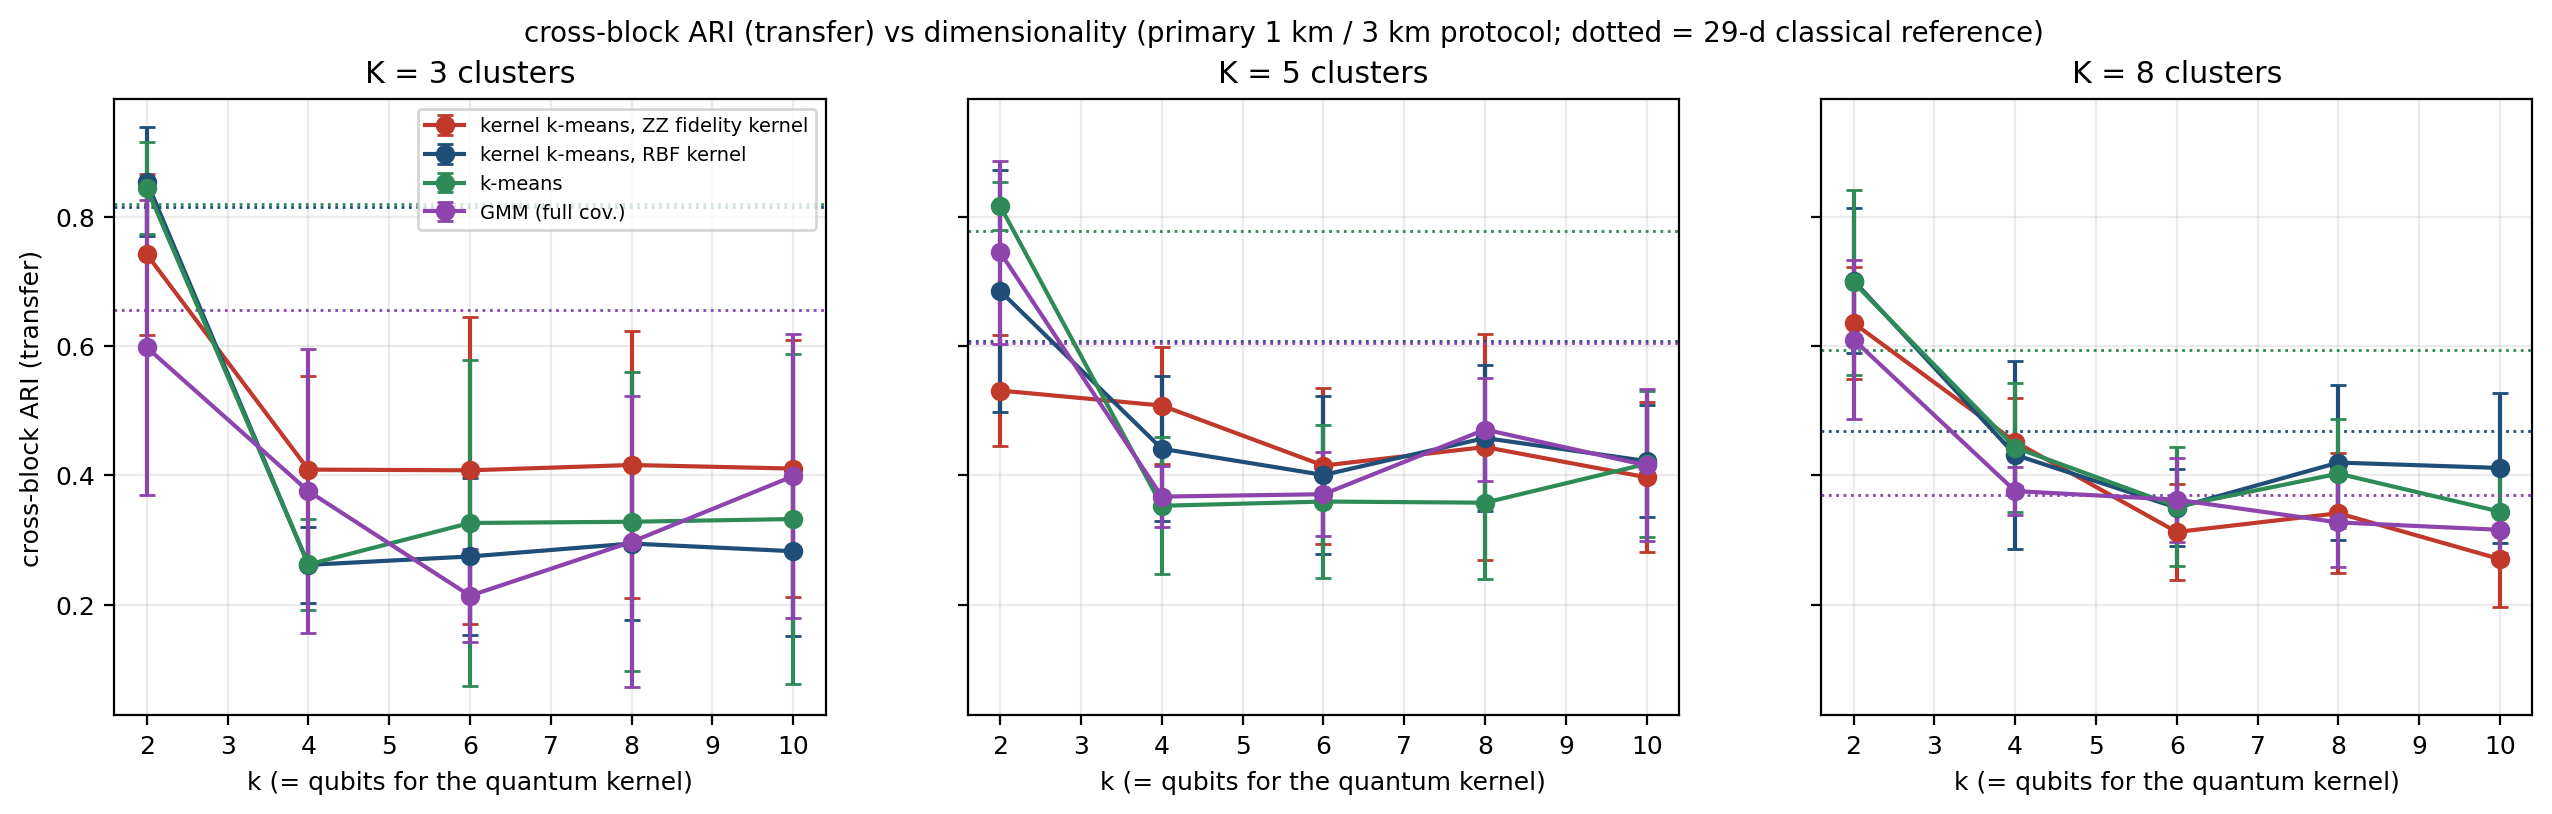

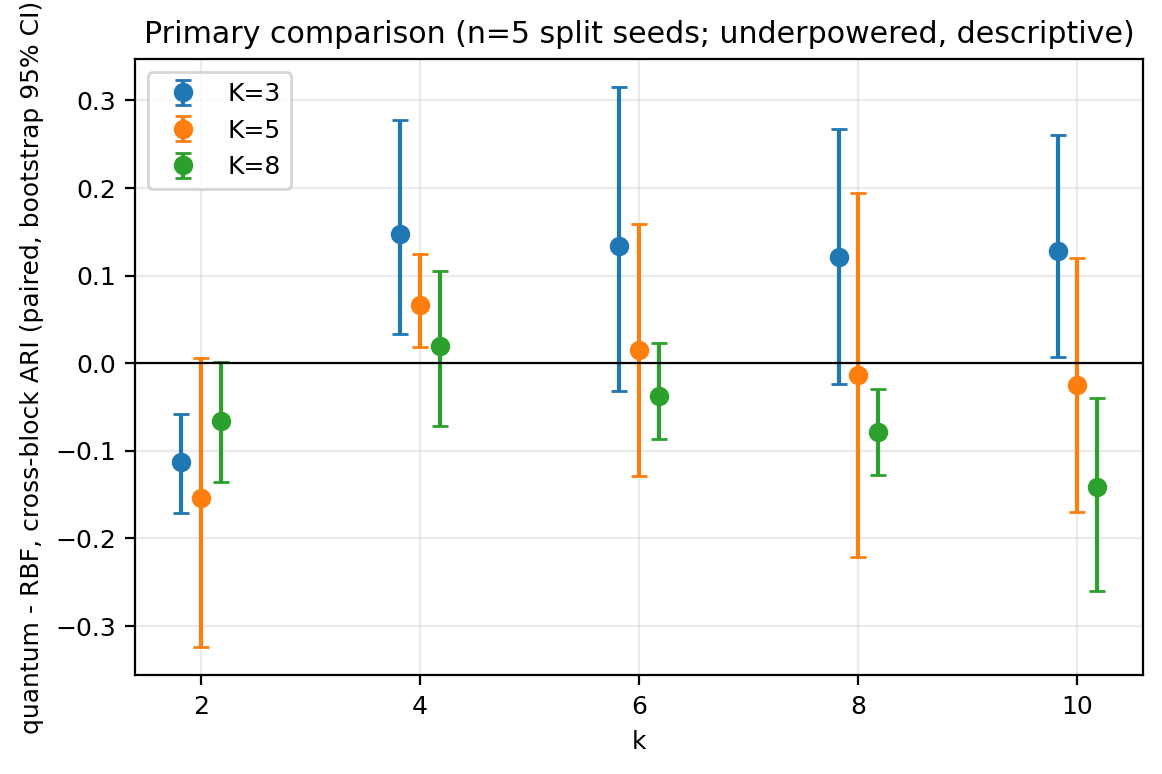

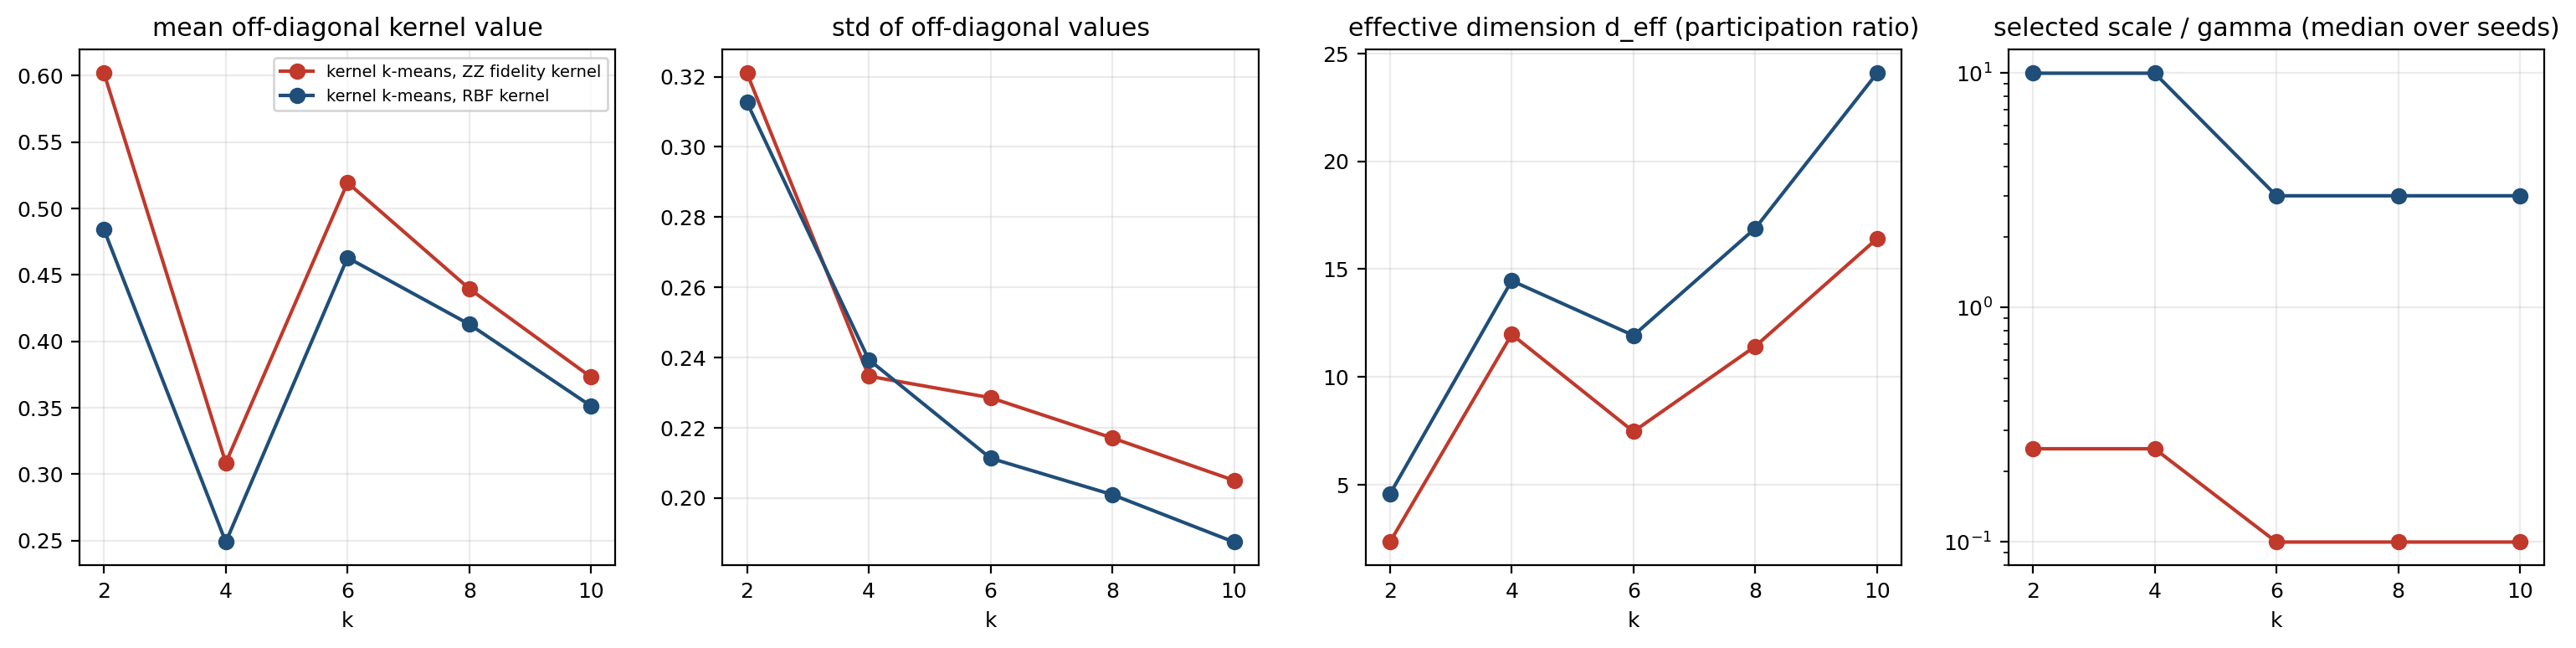

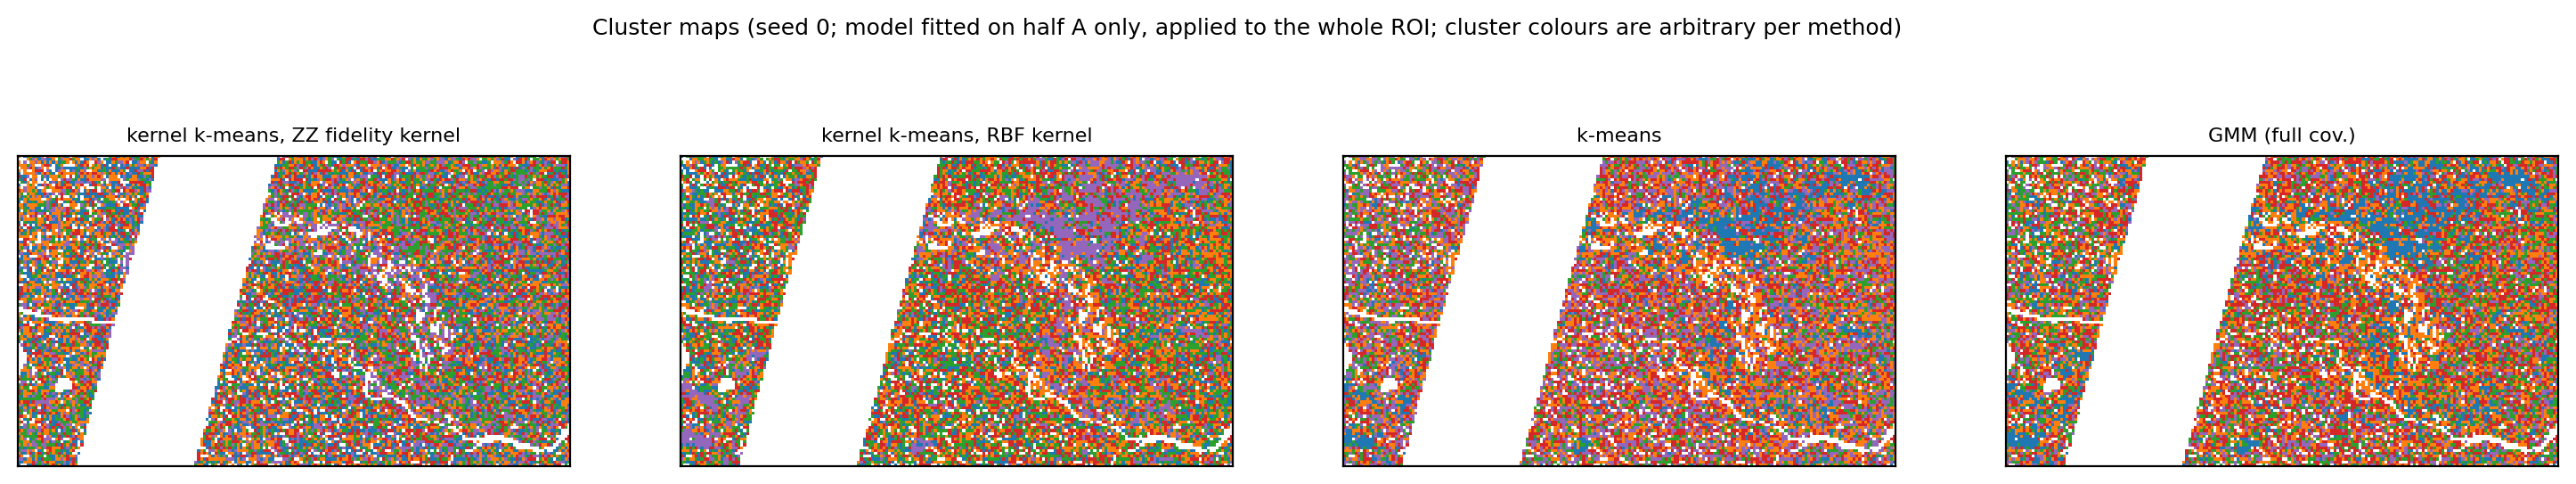

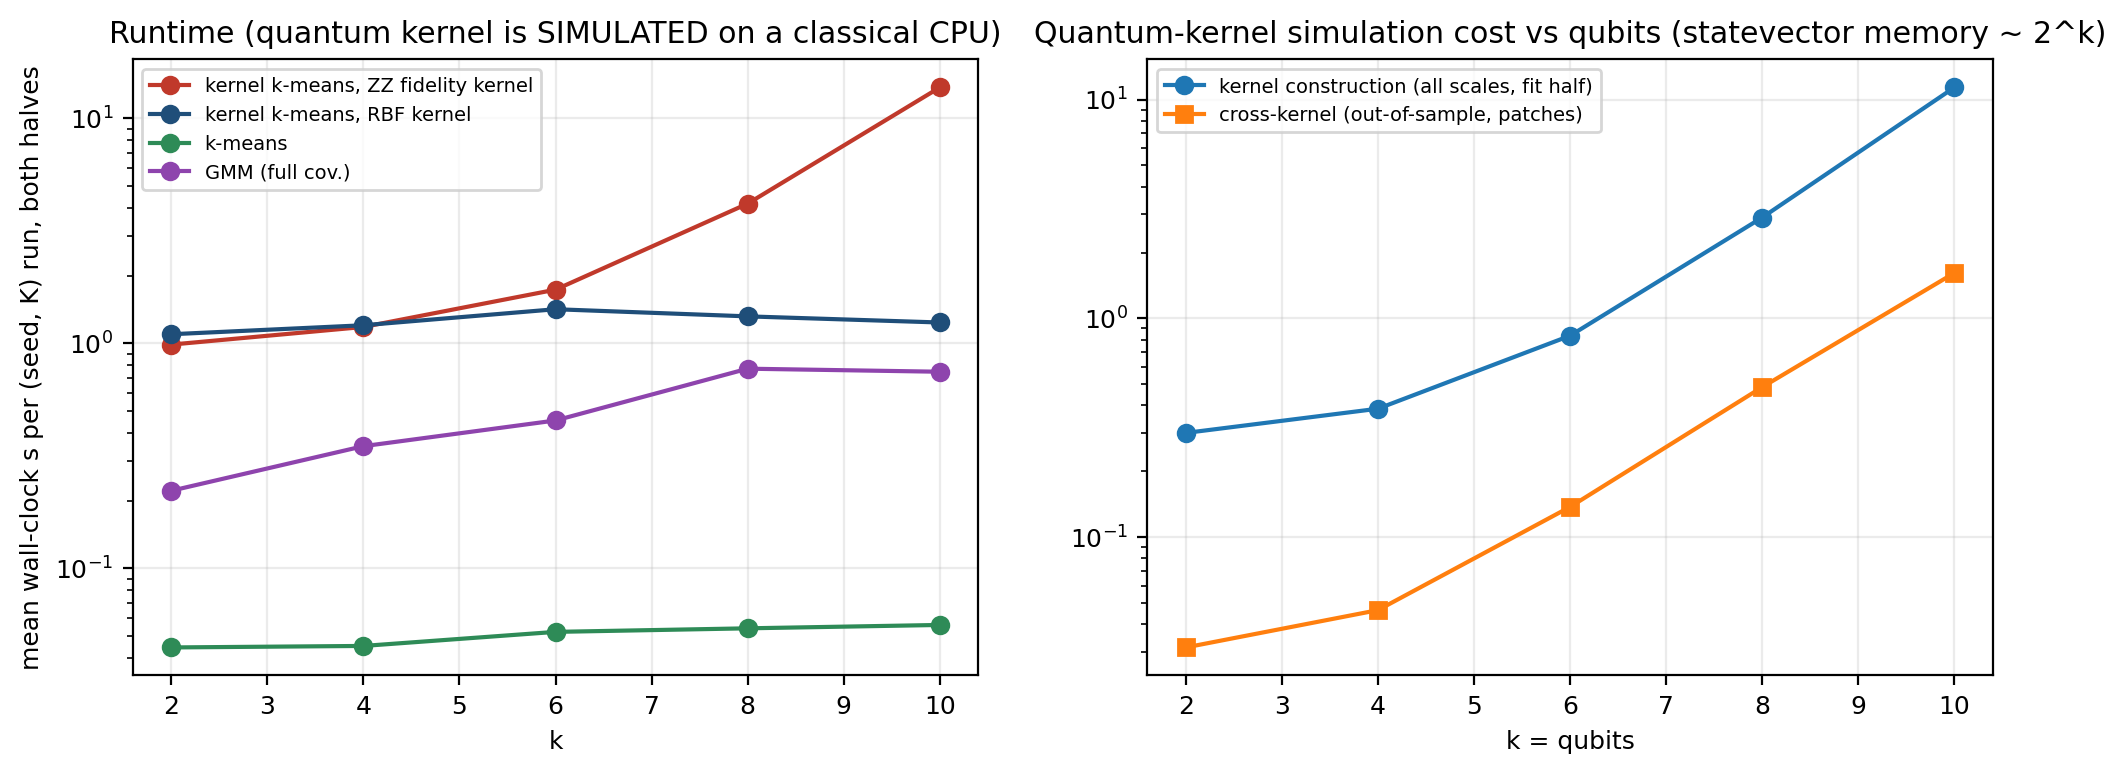

# Label-free classical vs quantum-kernel clustering: NISAR S-band GCOV, Jharia ROI

*Numeric sections are generated from result files. Sections marked **[AUTHOR TO WRITE]** need human interpretation. Pre-registration: `docs/PREREGISTRATION_UNSUPERVISED.md`. No labels were used; clusters are not classes; no accuracy exists.*

## Pre-registered evidence rule (primary metric: cross-block ARI, quantum vs RBF kernel k-means)
- Rule: quantum 'favourable' iff bootstrap 95% CI of paired difference in cross-block ARI is > 0 in >= 60% of (k,K) cells and < 0 in none (symmetric for classical); otherwise 'no consistent difference'
- Outcome: **NO CONSISTENT DIFFERENCE under the pre-registered rule**; cells: {'cells': 15, 'quantum_ci_above_zero': 3, 'rbf_ci_above_zero': 3}
- Other metrics (same rule, secondary): {"ari_cross": "NO CONSISTENT DIFFERENCE under the pre-registered rule", "ari_init": "NO CONSISTENT DIFFERENCE under the pre-registered rule", "coherence_kappa": "no data", "silhouette_common

In [ ]:
from IPython.display import Image, display
U='/content/nisar_qml_out/unsup'
for f in ['fig_ari_cross_vs_k','fig_primary_paired_difference','fig_kernel_diagnostics','fig_cluster_maps','fig_runtime']:
    p=f'{U}/figures/{f}.png'
    if os.path.exists(p): display(Image(p))
print(open(f'{U}/UNSUP_REPORT.md').read()[:6000])

In [ ]:
import shutil
shutil.make_archive('/content/NISAR_unsup_results','zip',U)
shutil.copy('/content/NISAR_unsup_results.zip','/content/drive/MyDrive/NISAR_unsup_results.zip'); print('saved NISAR_unsup_results.zip to Drive home')

saved NISAR_unsup_results.zip to Drive home


## Stage 3 amendments (post-hoc, see docs/PREREGISTRATION_UNSUPERVISED.md): coherence v2 + PCA-subspace overlap + scorecard
Re-runs Stage 3 with identical seeds into a NEW folder, checks that the original metrics reproduce the first real run, then builds the scorecard.

In [ ]:
!python run_pipeline.py config.yaml --unsup --set unsupervised.out_dir=/content/nisar_qml_out/unsup_v2

2026-10-06 06:16:09,732 INFO features (1305, 2319, 29), usable 2,160,423
2026-10-06 06:16:24,276 INFO [primary:primary_1km_gap_3km_block] seed 42 k=2 done (12 rows)
2026-10-06 06:16:41,911 INFO [primary:primary_1km_gap_3km_block] seed 42 k=4 done (24 rows)
2026-10-06 06:16:59,613 INFO [primary:primary_1km_gap_3km_block] seed 42 k=6 done (36 rows)
2026-10-06 06:17:20,624 INFO [primary:primary_1km_gap_3km_block] seed 42 k=8 done (48 rows)
2026-10-06 06:17:50,100 INFO [primary:primary_1km_gap_3km_block] seed 42 k=10 done (60 rows)
2026-10-06 06:18:33,267 INFO [primary:primary_1km_gap_3km_block] seed 42 k=full done (69 rows)
2026-10-06 06:18:46,769 INFO [primary:primary_1km_gap_3km_block] seed 7 k=2 done (81 rows)
2026-10-06 06:19:02,705 INFO [primary:primary_1km_gap_3km_block] seed 7 k=4 done (93 rows)
2026-10-06 06:19:20,228 INFO [primary:primary_1km_gap_3km_block] seed 7 k=6 done (105 rows)
2026-10-06 06:19:44,464 INFO [primary:primary_1km_gap_3km_block] seed 7 k=8 done (117 rows)
2026-

In [ ]:
# regression check: original metrics must equal the first real run (zip saved earlier in Drive home)
import zipfile, io, pandas as pd, numpy as np
z=zipfile.ZipFile('/content/drive/MyDrive/NISAR_unsup_results.zip'); old=pd.read_csv(io.BytesIO(z.read('results/all_runs.csv')))
new=pd.read_csv('/content/nisar_qml_out/unsup_v2/results/all_runs.csv')
m=old.merge(new,on=['protocol','seed','k','K','method'],suffixes=('_old','_new'))
for c in ['ari_cross','ari_init','silhouette_common','nmi_cross']:
    print(c,'max abs diff vs first run:',float(np.nanmax(np.abs(m[c+'_old']-m[c+'_new']))))
print('coherence v2 non-null rows:',int(new.coherence_kappa_v2.notna().sum()),'of',len(new),'| original coherence non-null:',int(new.coherence_kappa.notna().sum()))

ari_cross max abs diff vs first run: 0.0
ari_init max abs diff vs first run: 0.0
silhouette_common max abs diff vs first run: 0.0
nmi_cross max abs diff vs first run: 0.0


AttributeError: 'DataFrame' object has no attribute 'coherence_kappa_v2'

In [ ]:
# Stage 3 amendment regression check — robust version
import zipfile, io
import pandas as pd
import numpy as np

OLD_ZIP = "/content/drive/MyDrive/NISAR_unsup_results.zip"
NEW_CSV = "/content/nisar_qml_out/unsup_v2/results/all_runs.csv"

# Load original and v2 results
z = zipfile.ZipFile(OLD_ZIP)
old = pd.read_csv(io.BytesIO(z.read("results/all_runs.csv")))
new = pd.read_csv(NEW_CSV)

# Compare the original metrics
keys = ["protocol", "seed", "k", "K", "method"]
m = old.merge(
    new,
    on=keys,
    suffixes=("_old", "_new"),
    validate="one_to_one"
)

print("=" * 70)
print("STAGE 3 AMENDMENT REGRESSION CHECK")
print("=" * 70)

for c in ["ari_cross", "ari_init", "silhouette_common", "nmi_cross"]:
    diff = np.abs(m[f"{c}_old"] - m[f"{c}_new"])
    print(f"{c}: max abs diff = {float(np.nanmax(diff))}")

print("\nNew results shape:", new.shape)

# Robust coherence-column check
coh_v2 = "coherence_kappa_v2"
coh_old = "coherence_kappa"

if coh_v2 in new.columns:
    print(
        f"\ncoherence_kappa_v2 non-null rows: "
        f"{int(new[coh_v2].notna().sum())} of {len(new)}"
    )
else:
    print("\n⚠️ coherence_kappa_v2 column is absent from all_runs.csv")
    print("Available coherence/kappa columns:")
    for c in new.columns:
        if "coher" in c.lower() or "kappa" in c.lower():
            print("  ", c)

if coh_old in new.columns:
    print(
        f"Original coherence_kappa non-null rows: "
        f"{int(new[coh_old].notna().sum())}"
    )

print("\nRegression check completed.")

STAGE 3 AMENDMENT REGRESSION CHECK
ari_cross: max abs diff = 0.0
ari_init: max abs diff = 0.0
silhouette_common: max abs diff = 0.0
nmi_cross: max abs diff = 0.0

New results shape: (425, 28)

⚠️ coherence_kappa_v2 column is absent from all_runs.csv
Available coherence/kappa columns:
   coherence_kappa
   coherence_observed
Original coherence_kappa non-null rows: 40

Regression check completed.


In [ ]:
!python run_pipeline.py config.yaml --scorecard --set unsupervised.out_dir=/content/nisar_qml_out/unsup_v2

usage: run_pipeline.py [-h] [--set [SET ...]] [--stage1] [--stage1b]
                       [--label-audit] [--unsup]
                       config
run_pipeline.py: error: unrecognized arguments: --scorecard


In [ ]:
from IPython.display import Image, display
import os
import pandas as pd
import shutil

U = '/content/nisar_qml_out/unsup_v2'

# Display plots if they exist
for p in [f'{U}/scorecard/fig_scorecard_quantum_minus_best_classical.png', f'{U}/figures/fig_coherence_kappa_v2_vs_k.png']:
    if os.path.exists(p):
        display(Image(p))

# Safely load and display PCA subspace overlap if available
overlap_csv = f'{U}/results/pca_subspace_overlap.csv'
if os.path.exists(overlap_csv):
    df = pd.read_csv(overlap_csv)
    print(df.groupby('k')[['mean_cos2_overlap','max_principal_angle_deg']].mean().round(3))
else:
    print("Note: pca_subspace_overlap.csv not found in results directory.")

# Archive results and copy to drive
shutil.make_archive('/content/NISAR_unsup_v2_results', 'zip', U)
shutil.copy('/content/NISAR_unsup_v2_results.zip', '/content/drive/MyDrive/NISAR_unsup_v2_results.zip')
print('saved NISAR_unsup_v2_results.zip to Drive home')

Note: pca_subspace_overlap.csv not found in results directory.
saved NISAR_unsup_v2_results.zip to Drive home


In [ ]:
import os
import glob

results_dir = '/content/nisar_qml_out/unsup_v2/results'
if os.path.exists(results_dir):
    print("Files in results:", os.listdir(results_dir))
else:
    print("Results directory does not exist.")

all_files = glob.glob('/content/nisar_qml_out/**/*', recursive=True)
print(f"\nTotal files in output directory: {len(all_files)}")
for f in sorted(all_files)[:30]:
    if os.path.isfile(f):
        print("  ", f.replace('/content/nisar_qml_out/', ''))

Files in results: ['cluster_maps_seed0.npz', 'paired_quantum_vs_rbf.csv', 'all_runs.csv', 'eigen_spectra_seed0.npz', 'kernel_diagnostics.csv', 'runs_checkpoint.csv', 'summary_by_method_k_K.csv', 'quantum_resources.json']

Total files in output directory: 81
   label_audit/LABEL_AUDIT_SUMMARY.csv
   label_audit/LABEL_SOURCE_AUDIT.md
   label_audit/label_overlay.png
   label_audit/mining_polygon_roi.geojson
   label_audit/rasterization_spec.json
   label_audit/source/global_mining_polygons_v2.gpkg
   label_audit/source/validation_points_v2.gpkg
   logs/pipeline.log
   stage1/META.json
   stage1/STAGE1_QA.json
   stage1/STAGE1_QA.md
   stage1/config_effective_with_overrides.yaml
   stage1/config_used.yaml
   stage1/environment.json
   stage1/feature_summary.csv
   stage1/features.npz
   stage1/figures/stage1_diagnostics.png
   stage1/figures/stage1_quicklook.png
   stage1/roi_raw.npz
   stage1b/SPATIAL_RECONCILIATION.json
   stage1b/SPATIAL_RECONCILIATION.md
   stage1b/current_estimator_s

In [ ]:
from pathlib import Path

RESULTS = Path("/content/nisar_qml_out/unsup_v2/results")

print("=" * 70)
print("UNSUPERVISED V2 RESULTS")
print("=" * 70)

if not RESULTS.exists():
    print("❌ Results directory does not exist:")
    print(RESULTS)
else:
    files = sorted(RESULTS.iterdir())

    print(f"\nFound {len(files)} items:\n")

    for p in files:
        if p.is_file():
            print("✅", p.name)

    print("\nPCA/subspace-related files:")
    matches = [
        p for p in files
        if any(x in p.name.lower() for x in ["pca", "subspace", "overlap"])
    ]

    if matches:
        for p in matches:
            print("  ✅", p.name)
    else:
        print("  ❌ None found")

UNSUPERVISED V2 RESULTS

Found 8 items:

✅ all_runs.csv
✅ cluster_maps_seed0.npz
✅ eigen_spectra_seed0.npz
✅ kernel_diagnostics.csv
✅ paired_quantum_vs_rbf.csv
✅ quantum_resources.json
✅ runs_checkpoint.csv
✅ summary_by_method_k_K.csv

PCA/subspace-related files:
  ❌ None found


In [ ]:
from pathlib import Path
import shutil

U = Path("/content/nisar_qml_out/unsup_v2")
RESULTS = U / "results"

print("=" * 70)
print("UNSUPERVISED V2 — FINAL RESULTS PACKAGE")
print("=" * 70)

# Show actual results
files = sorted(RESULTS.iterdir())

print(f"\nResults directory: {RESULTS}")
print(f"Files found: {len(files)}\n")

for p in files:
    if p.is_file():
        print("✅", p.name)

# --------------------------------------------------
# Display figures only if they actually exist
# --------------------------------------------------

from IPython.display import Image, display

possible_figures = [
    U / "scorecard" / "fig_scorecard_quantum_minus_best_classical.png",
    U / "figures" / "fig_coherence_kappa_v2_vs_k.png",
]

print("\nFigures:")

for p in possible_figures:
    if p.exists():
        print("✅", p)
        display(Image(filename=str(p)))
    else:
        print("⚠️ Not generated:", p)

# --------------------------------------------------
# Optional: display method summary if available
# --------------------------------------------------

summary = RESULTS / "summary_by_method_k_K.csv"

if summary.exists():
    import pandas as pd

    print("\nSummary by method / k / K:")
    display(pd.read_csv(summary))

# --------------------------------------------------
# Package the actual results
# --------------------------------------------------

ARCHIVE_BASE = "/content/NISAR_unsup_v2_results"

archive = shutil.make_archive(
    ARCHIVE_BASE,
    "zip",
    root_dir=str(U)
)

print("\n" + "=" * 70)
print("PACKAGE CREATED")
print("=" * 70)

print(archive)

# Copy to Drive
DRIVE_DEST = "/content/drive/MyDrive/NISAR_unsup_v2_results_gpt.zip"

shutil.copy2(archive, DRIVE_DEST)

print("\n✅ Saved to Google Drive:")
print(DRIVE_DEST)

UNSUPERVISED V2 — FINAL RESULTS PACKAGE

Results directory: /content/nisar_qml_out/unsup_v2/results
Files found: 8

✅ all_runs.csv
✅ cluster_maps_seed0.npz
✅ eigen_spectra_seed0.npz
✅ kernel_diagnostics.csv
✅ paired_quantum_vs_rbf.csv
✅ quantum_resources.json
✅ runs_checkpoint.csv
✅ summary_by_method_k_K.csv

Figures:
⚠️ Not generated: /content/nisar_qml_out/unsup_v2/scorecard/fig_scorecard_quantum_minus_best_classical.png
⚠️ Not generated: /content/nisar_qml_out/unsup_v2/figures/fig_coherence_kappa_v2_vs_k.png

Summary by method / k / K:


,method,k,K,ari_cross_mean,ari_cross_std,ari_init_mean,ari_init_std,coherence_kappa_mean,coherence_kappa_std,silhouette_common_mean,silhouette_common_std,nmi_cross_mean,nmi_cross_std,min_cluster_frac_mean,min_cluster_frac_std
0,gmm,2,3,0.598164,0.228030,0.983216,0.016761,NaN,NaN,0.379029,0.032015,0.633800,0.150084,0.147600,0.037219
1,gmm,2,5,0.745389,0.141174,0.595449,0.124049,NaN,NaN,0.365888,0.009900,0.736261,0.069658,0.050400,0.025266
2,gmm,2,8,0.610396,0.122711,0.774044,0.100983,NaN,NaN,0.323090,0.007533,0.708879,0.047052,0.031467,0.011761
3,gmm,4,3,0.375563,0.220011,0.684827,0.218881,NaN,NaN,0.187836,0.011925,0.380054,0.174460,0.211333,0.049887
4,gmm,4,5,0.367167,0.047240,0.887051,0.110457,NaN,NaN,0.175413,0.005706,0.429839,0.032191,0.097333,0.013400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,kmeans,10,5,0.417865,0.113249,0.759316,0.124116,NaN,NaN,0.102751,0.003114,0.458246,0.073800,0.073867,0.014294
65,kmeans,10,8,0.343769,0.067429,0.667973,0.031186,NaN,NaN,0.097306,0.003166,0.443315,0.054503,0.030267,0.014005
66,kmeans,full,3,0.820295,0.144594,0.999368,0.000912,NaN,NaN,0.187628,0.003825,0.793549,0.115030,0.144667,0.023944
67,kmeans,full,5,0.778432,0.052662,0.911956,0.072239,NaN,NaN,0.150499,0.004561,0.763099,0.045394,0.050133,0.006208



PACKAGE CREATED
/content/NISAR_unsup_v2_results.zip

✅ Saved to Google Drive:
/content/drive/MyDrive/NISAR_unsup_v2_results_gpt.zip


In [ ]:
import shutil, zipfile, os
shutil.rmtree('/content/nisar_qml', ignore_errors=True)
zp = '/content/drive/MyDrive/nisar_qml_project.zip'
print('zip size on Drive:', os.path.getsize(zp), '(new version = 90028 bytes)')
zipfile.ZipFile(zp).extractall('/content')
os.chdir('/content/nisar_qml')
assert 'coherence_kappa_v2' in open('nisar_qml/unsup.py').read(), 'still the OLD zip: re-download from the chat and replace it in Drive'
print('amended version confirmed')
!python run_pipeline.py config.yaml --unsup --set unsupervised.out_dir=/content/nisar_qml_out/unsup_v2_amended
!python run_pipeline.py config.yaml --scorecard --set unsupervised.out_dir=/content/nisar_qml_out/unsup_v2_amended

zip size on Drive: 90028 (new version = 90028 bytes)
amended version confirmed
2026-10-06 07:24:03,433 INFO features (1305, 2319, 29), usable 2,160,423
2026-10-06 07:24:18,594 INFO [primary:primary_1km_gap_3km_block] seed 42 k=2 done (12 rows)
2026-10-06 07:24:34,874 INFO [primary:primary_1km_gap_3km_block] seed 42 k=4 done (24 rows)
2026-10-06 07:24:51,925 INFO [primary:primary_1km_gap_3km_block] seed 42 k=6 done (36 rows)
2026-10-06 07:25:12,388 INFO [primary:primary_1km_gap_3km_block] seed 42 k=8 done (48 rows)
2026-10-06 07:25:46,399 INFO [primary:primary_1km_gap_3km_block] seed 42 k=10 done (60 rows)
2026-10-06 07:26:31,399 INFO [primary:primary_1km_gap_3km_block] seed 42 k=full done (69 rows)
2026-10-06 07:26:45,940 INFO [primary:primary_1km_gap_3km_block] seed 7 k=2 done (81 rows)
2026-10-06 07:27:00,758 INFO [primary:primary_1km_gap_3km_block] seed 7 k=4 done (93 rows)
2026-10-06 07:27:17,518 INFO [primary:primary_1km_gap_3km_block] seed 7 k=6 done (105 rows)
2026-10-06 07:27:3

In [ ]:
import os, io, zipfile, shutil
import pandas as pd, numpy as np
U = '/content/nisar_qml_out/unsup_v2_amended'
os.chdir('/content/nisar_qml')

# 1) scorecard (skips if already built)
if not os.path.exists(f'{U}/scorecard/scorecard_cells.csv'):
    !python run_pipeline.py config.yaml --scorecard --set unsupervised.out_dir={U}

# 2) regression vs the FIRST real run: original metrics must be unchanged
old = pd.read_csv(io.BytesIO(zipfile.ZipFile('/content/drive/MyDrive/NISAR_unsup_results.zip').read('results/all_runs.csv')))
new = pd.read_csv(f'{U}/results/all_runs.csv')
m = old.merge(new, on=['protocol','seed','k','K','method'], suffixes=('_old','_new'))
for c in ['ari_cross','ari_init','silhouette_common','nmi_cross']:
    print(c, 'max abs diff vs first run:', float(np.nanmax(np.abs(m[c+'_old']-m[c+'_new']))))

# 3) amendments present?
print('v2 columns:', [c for c in new.columns if 'v2' in c])
print('coherence v2 non-null rows:', int(new.coherence_kappa_v2.notna().sum()), 'of', len(new),
      '| original coherence non-null:', int(new.coherence_kappa.notna().sum()))
print('pca file:', os.path.exists(f'{U}/results/pca_subspace_overlap.csv'))
print(pd.read_csv(f'{U}/results/pca_subspace_overlap.csv').groupby('k')[['mean_cos2_overlap','max_principal_angle_deg']].mean().round(3))

# 4) one zip in Drive home
shutil.make_archive('/content/NISAR_unsup_amended','zip',U)
shutil.copy('/content/NISAR_unsup_amended.zip','/content/drive/MyDrive/NISAR_unsup_amended.zip')
print('saved NISAR_unsup_amended.zip to Drive home')

ari_cross max abs diff vs first run: 0.0
ari_init max abs diff vs first run: 0.0
silhouette_common max abs diff vs first run: 0.0
nmi_cross max abs diff vs first run: 0.0
v2 columns: ['coherence_kappa_v2', 'coherence_v2_observed', 'n_patches_v2']
coherence v2 non-null rows: 425 of 425 | original coherence non-null: 40
pca file: True
    mean_cos2_overlap  max_principal_angle_deg
k                                             
2               0.991                    6.751
4               0.946                   24.287
6               0.941                   33.654
8               0.981                   19.243
10              0.994                    9.865
saved NISAR_unsup_amended.zip to Drive home


**Stopped here by design.** The Maus v2 files were downloaded ONLY for the feasibility audit. No model has been trained, no label has been approved, and `labels.review.*` are all `false`, so training is blocked in code.

Upload to the chat: `LABEL_SOURCE_AUDIT.md`, `LABEL_AUDIT_SUMMARY.csv`, `mining_polygon_roi.geojson`, `label_overlay.png` (also zipped as `NISAR_label_audit.zip` in your Drive home).
